# Part 1 - Converts lammpstrj to a csv with timestep as an additional column

Input - lammpstrj file
Output - csv file (filename a tthe end can be changed)

In [1]:
import pandas as pd
import numpy as np

def lammpstrj_to_df(filepath):
    """
    Reorganize a LAMMPS .lammpstrj into a flat table where each atom row
    is tagged with its frame's TIMESTEP.

    Output columns (in order):
      timestep, id, mol, type, x, y, z, xu, yu, zu

    Any of the coordinate columns missing in the file will be filled with NaN.
    """
    keep = ["id","mol","type","x","y","z","xu","yu","zu"]
    rows = []

    timestep = None
    reading_atoms = False
    col_idx = {}

    with open(filepath, "r") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue

            # TIMESTEP block: next line is the timestep value
            if s.startswith("ITEM: TIMESTEP"):
                ts_line = next(f).strip()
                timestep = int(float(ts_line.split()[0]))
                reading_atoms = False
                continue

            # ATOMS header: defines which columns follow on subsequent lines
            if s.startswith("ITEM: ATOMS"):
                parts = s.split()
                atom_cols = parts[2:]                 # columns after "ITEM:" "ATOMS"
                col_idx = {c: i for i, c in enumerate(atom_cols)}
                reading_atoms = True
                continue

            # Any other ITEM section ends the atom rows block
            if s.startswith("ITEM:"):
                reading_atoms = False
                continue

            # Atom data line
            if reading_atoms and timestep is not None:
                toks = s.split()
                row = {"timestep": timestep}
                for c in keep:
                    if c in col_idx and col_idx[c] < len(toks):
                        v = toks[col_idx[c]]
                        try:
                            row[c] = float(v)
                        except ValueError:
                            row[c] = np.nan
                    else:
                        row[c] = np.nan
                rows.append(row)

    # Build DataFrame with the requested column order
    df = pd.DataFrame(rows, columns=["timestep"] + keep)

    # Dtypes: ints where possible, floats for coordinates
    for c in ["timestep", "id", "mol", "type"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        # use nullable Int64 so NaNs are allowed
        if df[c].isna().any():
            df[c] = df[c].astype("Int64")
        else:
            df[c] = df[c].astype("int64")

    for c in ["x","y","z","xu","yu","zu"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df



traj_path4 = "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P2/Replica1/linear.lammpstrj"
df4 = lammpstrj_to_df(traj_path4)
print(df4.head())
df4.to_csv("P2_with_timestep_Replica1.csv", index=False)

traj_path5 = "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P2/Replica2/linear.lammpstrj"
df5 = lammpstrj_to_df(traj_path5)
print(df5.head())
df5.to_csv("P2_with_timestep_Replica2.csv", index=False)

traj_path6 = "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P2/Replica3/linear.lammpstrj"
df6 = lammpstrj_to_df(traj_path6)
print(df6.head())
df6.to_csv("P2_with_timestep_Replica3.csv", index=False)

   timestep     id   mol  type        x        y        z       xu       yu  \
0         0  34918  2044    12 -29.2928 -30.4153 -32.7139  43.6751 -30.4153   
1         0  34919  2044    11 -28.6675 -30.7648 -31.9380  44.3005 -30.7648   
2         0  34920  2044    11 -29.2459 -29.3775 -32.7374  43.7221 -29.3775   
3         0  31168   794    12 -29.9210 -32.6867 -34.2768  43.0470 -32.6867   
4         0  31169   794    11 -29.5847 -31.8607 -33.9146  43.3833 -31.8607   

        zu  
0  40.2540  
1  41.0300  
2  40.2306  
3  38.6911  
4  39.0533  
   timestep     id   mol  type        x        y        z        xu       yu  \
0         0  35883  2365    11 -29.8404 -28.9164 -34.9235   43.0671  2887.39   
1         0  44720  5311    11 -32.8583 -28.7176 -35.2875 -105.7660  2887.58   
2         0  44721  5311    11 -34.0663 -29.6794 -35.1970 -106.9740  2886.62   
3         0  33896  1703    11 -33.4965 -31.8231 -36.0278   39.4110  2811.57   
4         0  44719  5311    12 -33.4843 -29.085

# Part 2 - Filters out the correct type of molecule

In [2]:
def make_type9(in_csv, out_csv, chunk=2_000_000):
    wrote = False
    total = 0

    for df in pd.read_csv(in_csv, chunksize=chunk):
        df.columns = [c.strip() for c in df.columns]
        if "type" not in df.columns:
            raise ValueError(f"'type' column not found in {in_csv}")

        df10 = df[df["type"] == 9]
        if len(df10) == 0:
            continue

        df10.to_csv(out_csv, index=False, mode="w" if not wrote else "a", header=not wrote)
        wrote = True
        total += len(df10)

    if not wrote:
        # create an empty file with header (rare)
        pd.DataFrame(columns=df.columns).to_csv(out_csv, index=False)

    print(f"[OK] {out_csv} written rows (type==9): {total}")

# IMPORTANT: use your ORIGINAL replica CSVs (NOT the empty type10 ones)
make_type9("P2_with_timestep_Replica1.csv", "P2_with_timestep_Replica1_type9.csv")
make_type9("P2_with_timestep_Replica2.csv", "P2_with_timestep_Replica2_type9.csv")
make_type9("P2_with_timestep_Replica3.csv", "P2_with_timestep_Replica3_type9.csv")

[OK] P2_with_timestep_Replica1_type9.csv written rows (type==9): 480480
[OK] P2_with_timestep_Replica2_type9.csv written rows (type==9): 480480
[OK] P2_with_timestep_Replica3_type9.csv written rows (type==9): 480480


# Part 3 - Calculates the displacements

1. Identify all reactions (condition is if timestep > 1000) 
2. Calculates cumulative displacement vectors by molecule for both disc and cont.
3. Squares the vectors, calculates dot products and total vectors.

P2_with_timestep_Replica1_type9.csv: agg rows = 1001
P2_with_timestep_Replica3_type9.csv: agg rows = 1001
P2_with_timestep_Replica3_type9.csv: agg rows = 1001
[OK] Saved averaged CSV: P2_type9_replica_average_meanStd.csv


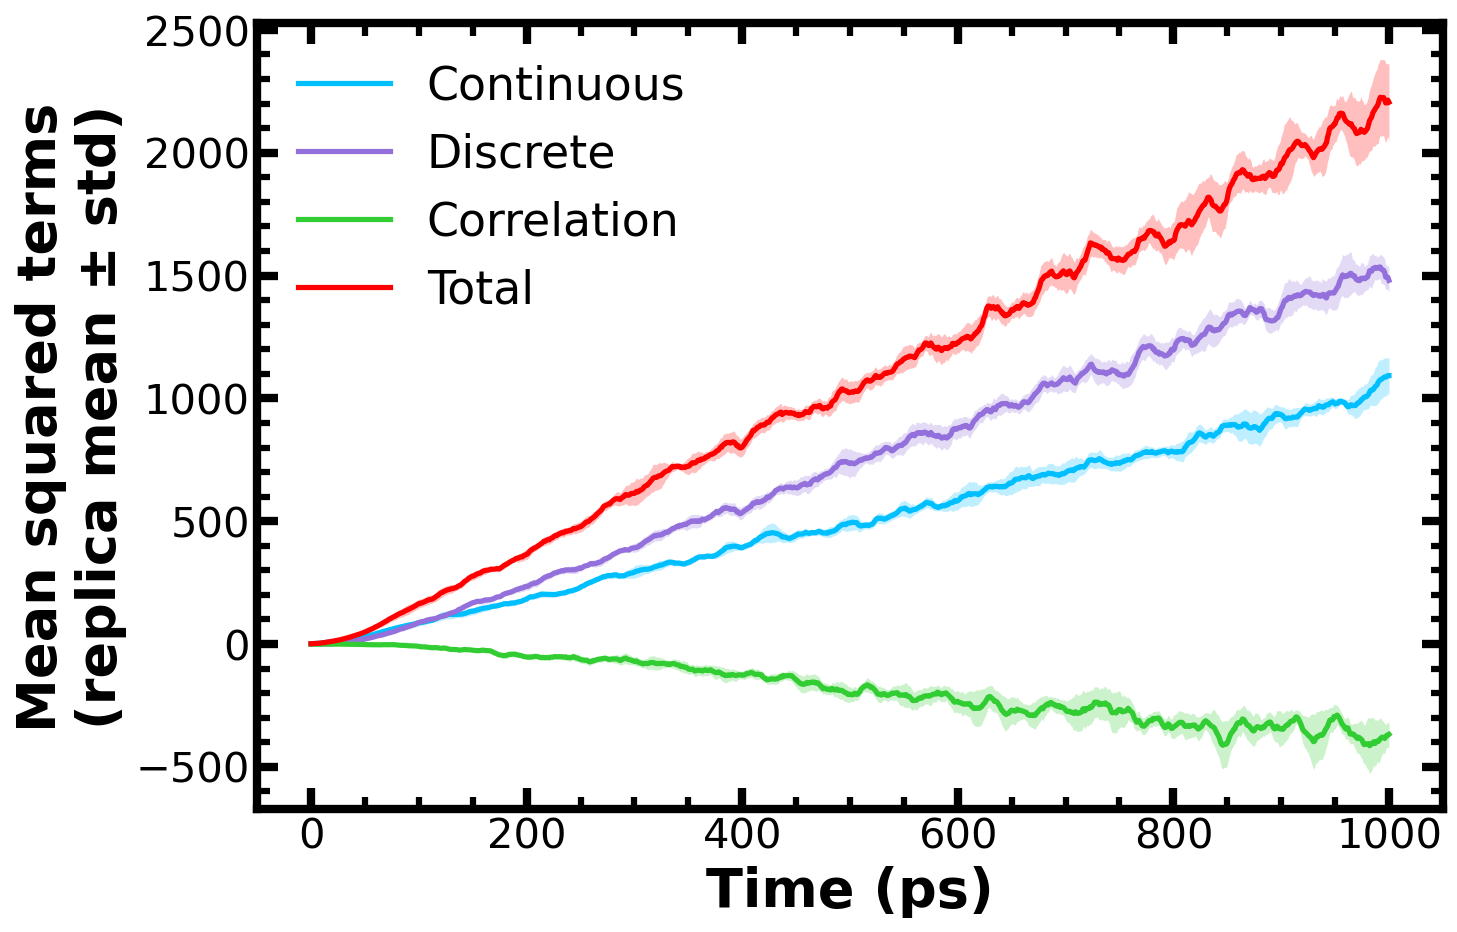

[OK] Saved plot: P2_type9_squared_terms_ACS_mean_with_band.png
[OK] Saved plot: P2_type9_squared_terms_ACS_mean_with_band.pdf


In [4]:
#!/usr/bin/env python3
"""
End-to-end (ACS-style) script for 3 replicas (type==10 CSVs):

1) Read each replica CSV
2) Split increments into continuous vs discrete jumps using THRESH on forward timestep gap
3) Build cumulative displacement vectors per ID
4) Compute:
     cont_sq = |Rc|^2
     disc_sq = |Rd|^2
     corr    = 2 Rc·Rd
     total   = cont + disc + corr
5) Average across IDs within each replica at each time
6) Align replicas on a common time grid (union + interpolation)
7) Compute replica mean ± std at each time
8) Save averaged CSV for later system comparisons
9) Plot mean curves + shadow bands using your requested colors
   - Total red, Discrete purple, Correlation green, Continuous blue
   - X-axis in picoseconds (assuming 1 fs timestep in LAMMPS real units)
   - Y-label in two lines
"""

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# -----------------------------
# USER SETTINGS
# -----------------------------
SYSTEM_TAG = "P2_type9"

IN_CSVS = [
    "P2_with_timestep_Replica1_type9.csv",
    "P2_with_timestep_Replica3_type9.csv",
    "P2_with_timestep_Replica3_type9.csv",
]

THRESH = 1000   # next timestep gap > THRESH => current step is DISCRETE
DT_FS  = 1.0    # LAMMPS timestep size in femtoseconds (units real). Change if your timestep is not 1.0 fs.

# outputs
OUT_AVG_CSV = f"{SYSTEM_TAG}_replica_average_meanStd.csv"
OUT_PNG = f"{SYSTEM_TAG}_squared_terms_ACS_mean_with_band.png"
OUT_PDF = f"{SYSTEM_TAG}_squared_terms_ACS_mean_with_band.pdf"

# band/line appearance
ALPHA_BAND = 0.35
LINE_W = 3.0
AX_W = 4.0
TICK_W = 4.0
TICK_LEN = 10

# optional smoothing (set 0 to disable)
SMOOTH_WINDOW = 15

# -----------------------------
# COLORS (match your reference)
# -----------------------------
COL_CONT  = "#1f9bcf"  # blue
COL_DISC  = "#7a3fa0"  # purple
COL_CORR  = "#1aa64b"  # green
COL_TOTAL = "#e21a1a"  # red

# -----------------------------
# ACS-LIKE STYLE
# -----------------------------
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.default": "regular",

    "font.size": 16,
    "axes.labelsize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 22,

    "axes.linewidth": AX_W,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

def smooth_series(y, w):
    if w is None or w <= 1:
        return y
    return pd.Series(y).rolling(window=w, center=True, min_periods=max(2, w//3)).mean().to_numpy()

# -----------------------------
# PER-REPLICA AGGREGATION
# -----------------------------
def compute_agg_squared_terms(csv_path: str, thresh: int) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df.columns = [str(c).strip() for c in df.columns]

    time_col = "t_rebased" if "t_rebased" in df.columns else "timestep"
    coord_cols = ("xu","yu","zu") if {"xu","yu","zu"}.issubset(df.columns) else ("x","y","z")

    df = df[["id", time_col, *coord_cols]].copy()

    df["id"] = pd.to_numeric(df["id"], errors="coerce").astype("Int64")
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce").astype("Int64")
    for c in coord_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("float32")

    df = df.dropna().astype({"id": int, time_col: int})
    df = df.sort_values(["id", time_col], kind="mergesort").reset_index(drop=True)

    # per-step diffs within id
    dxyz = df.groupby("id", sort=False)[list(coord_cols)].diff().astype("float32")
    dxyz.columns = ["dx","dy","dz"]
    df = pd.concat([df, dxyz], axis=1).fillna({"dx":0.0,"dy":0.0,"dz":0.0})

    # discrete detection: forward time gap
    next_dt = df.groupby("id", sort=False)[time_col].shift(-1) - df[time_col]
    is_disc = (next_dt > thresh).fillna(False).to_numpy()
    first_idx = df.groupby("id", sort=False).head(1).index
    is_disc[first_idx] = False

    dx = df["dx"].to_numpy(np.float32)
    dy = df["dy"].to_numpy(np.float32)
    dz = df["dz"].to_numpy(np.float32)

    # split increments
    dx_disc = np.where(is_disc, dx, 0.0).astype("float32")
    dy_disc = np.where(is_disc, dy, 0.0).astype("float32")
    dz_disc = np.where(is_disc, dz, 0.0).astype("float32")

    dx_cont = np.where(~is_disc, dx, 0.0).astype("float32")
    dy_cont = np.where(~is_disc, dy, 0.0).astype("float32")
    dz_cont = np.where(~is_disc, dz, 0.0).astype("float32")

    df["dx_disc"], df["dy_disc"], df["dz_disc"] = dx_disc, dy_disc, dz_disc
    df["dx_cont"], df["dy_cont"], df["dz_cont"] = dx_cont, dy_cont, dz_cont

    # cumulative vectors per id
    df[["cum_dx_disc","cum_dy_disc","cum_dz_disc"]] = df.groupby("id", sort=False)[["dx_disc","dy_disc","dz_disc"]].cumsum()
    df[["cum_dx_cont","cum_dy_cont","cum_dz_cont"]] = df.groupby("id", sort=False)[["dx_cont","dy_cont","dz_cont"]].cumsum()

    Rx = df["cum_dx_cont"].to_numpy(np.float64)
    Ry = df["cum_dy_cont"].to_numpy(np.float64)
    Rz = df["cum_dz_cont"].to_numpy(np.float64)

    Sx = df["cum_dx_disc"].to_numpy(np.float64)
    Sy = df["cum_dy_disc"].to_numpy(np.float64)
    Sz = df["cum_dz_disc"].to_numpy(np.float64)

    cont_sq = Rx*Rx + Ry*Ry + Rz*Rz
    disc_sq = Sx*Sx + Sy*Sy + Sz*Sz
    corr = 2.0*(Rx*Sx + Ry*Sy + Rz*Sz)
    total = cont_sq + disc_sq + corr

    df["cont_sq"] = cont_sq
    df["disc_sq"] = disc_sq
    df["corr"] = corr
    df["total"] = total

    # average across IDs at each time
    agg = (
        df.groupby(time_col, sort=True)[["cont_sq","disc_sq","corr","total"]]
          .mean()
          .reset_index()
          .rename(columns={time_col: "time"})
          .sort_values("time")
          .reset_index(drop=True)
    )
    return agg

# -----------------------------
# REPLICA ALIGNMENT + MEAN/STD
# -----------------------------
def replica_mean_std(rep_aggs):
    terms = ["cont_sq","disc_sq","corr","total"]

    # union time grid across replicas
    tgrid = np.unique(np.concatenate([a["time"].to_numpy(dtype=float) for a in rep_aggs]))
    tgrid.sort()

    interp = {term: [] for term in terms}
    for a in rep_aggs:
        aa = a.sort_values("time").groupby("time", as_index=False)[terms].mean()
        tx = aa["time"].to_numpy(dtype=float)
        for term in terms:
            y = aa[term].to_numpy(dtype=float)
            interp[term].append(np.interp(tgrid, tx, y))

    out = pd.DataFrame({"time": tgrid.astype(np.int64)})
    for term in terms:
        arr = np.vstack(interp[term])  # (nrep, ntime)
        out[f"{term}_mean"] = arr.mean(axis=0)
        out[f"{term}_std"]  = arr.std(axis=0, ddof=1)
    return out

# -----------------------------
# RUN
# -----------------------------
rep_aggs = []
for p in IN_CSVS:
    a = compute_agg_squared_terms(p, THRESH)
    print(f"{p}: agg rows = {len(a)}")
    rep_aggs.append(a)

ms = replica_mean_std(rep_aggs)

# Save averaged CSV (mean + std) for later system-comparison plots
ms.to_csv(OUT_AVG_CSV, index=False)
print(f"[OK] Saved averaged CSV: {OUT_AVG_CSV}")

# -----------------------------
# PLOT (ACS + requested colors)
# -----------------------------
# Convert timestep -> ps: time(ps) = timestep * DT_FS * 0.001
x_ps = ms["time"].to_numpy(dtype=float) * DT_FS * 0.001

# COL_CONT  = "#2C7FB8"   # blue
# COL_DISC  = "#DA70D6"   # purple
# COL_CORR  = "#1A9850"   # green
# COL_TOTAL = "#FF0000"   # firebrick red
COL_CONT  = "deepskyblue"
COL_DISC  = "mediumpurple"
COL_CORR  = "limegreen"
COL_TOTAL = "#FF0000"

ALPHA_BAND = 0.25
LINE_W = 2.5

def plot_mean_band(mean_col, std_col, label, color):
    mean = smooth_series(ms[mean_col].to_numpy(), SMOOTH_WINDOW)
    std  = smooth_series(ms[std_col].to_numpy(),  SMOOTH_WINDOW)
    plt.plot(x_ps, mean, linewidth=LINE_W, color=color, label=label)
    plt.fill_between(x_ps, mean - std, mean + std, color=color, alpha=ALPHA_BAND, linewidth=0)

plt.figure(figsize=(10, 6.5))

plot_mean_band("cont_sq_mean","cont_sq_std", "Continuous",  COL_CONT)
plot_mean_band("disc_sq_mean","disc_sq_std", "Discrete",    COL_DISC)
plot_mean_band("corr_mean","corr_std",       "Correlation", COL_CORR)
plot_mean_band("total_mean","total_std",     "Total",       COL_TOTAL)

ax = plt.gca()
ax.tick_params(which="major", width=TICK_W, length=TICK_LEN, top=True, right=True)
ax.tick_params(which="minor", width=max(1, TICK_W-1), length=max(4, TICK_LEN-4), top=True, right=True)
ax.minorticks_on()

plt.xlabel("Time (ps)", fontweight="bold")
plt.ylabel("Mean squared terms\n(replica mean ± std)", fontweight="bold")
plt.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig(OUT_PNG, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")
plt.show()

print(f"[OK] Saved plot: {OUT_PNG}")
print(f"[OK] Saved plot: {OUT_PDF}")